✅ df rows: 10


,Movie,Budget_EUR,Revenue_EUR,Rating_Value,Rating_Count,Opening_EUR,TicketPrice_EUR,Country,Main_Genre,ROI
0,ne zha 2,68000000.0,1.916284e+09,7.9,22517.0,676400000.0,NaN,NaN,Action,28.180650
1,zootopia 2,127000000.0,1.507670e+09,7.5,71981.0,271724258.0,NaN,NaN,Action,11.871417
2,avatar: fire and ash,297000000.0,1.200040e+09,7.4,123930.0,57527285.0,NaN,NaN,Action,4.040539
3,lilo & stitch,84000000.0,8.802266e+08,6.7,90450.0,8662679.0,NaN,NaN,Action,10.478888
4,a minecraft movie,127000000.0,8.126089e+08,5.6,152328.0,14500000.0,NaN,NaN,Action,6.398495
5,jurassic world: rebirth,170000000.0,7.370186e+08,5.8,176442.0,25780714.0,NaN,NaN,Action,4.335403
6,demon slayer,16000000.0,6.191955e+08,8.4,62454.0,NaN,NaN,NaN,NaN,38.699719
7,how to train your dragon,127000000.0,5.396130e+08,7.7,121237.0,11090905.0,NaN,NaN,Action,4.248922
8,f1: the movie,212000000.0,5.357897e+08,7.7,304904.0,9000000.0,NaN,NaN,Action,2.527310
9,superman,190000000.0,5.230542e+08,7.1,385548.0,NaN,NaN,NaN,Action,2.752917


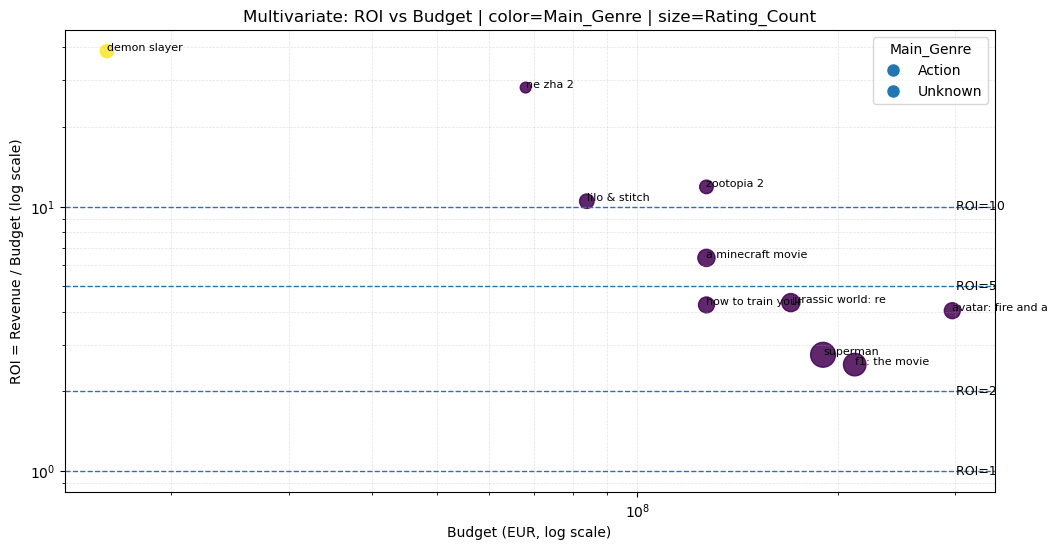

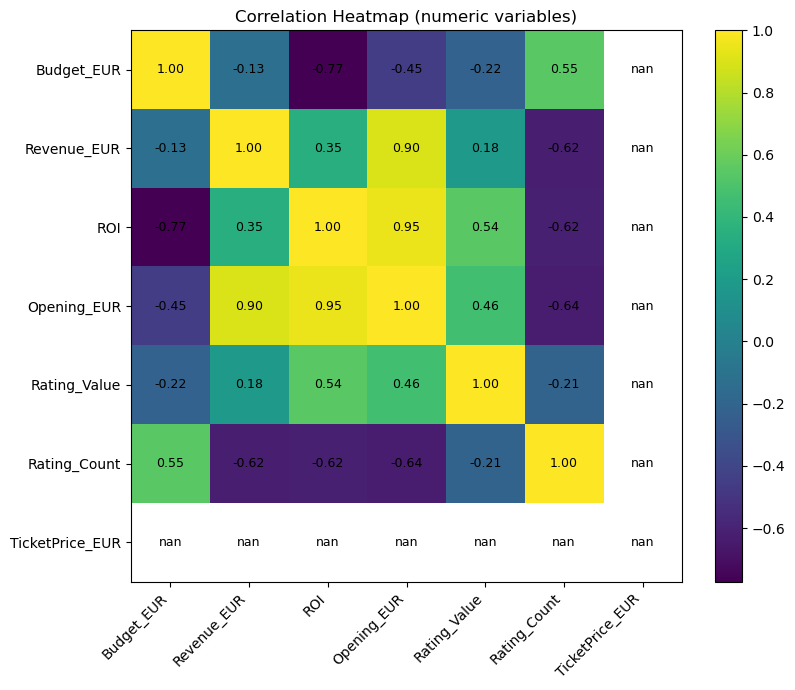

C:\Users\cheng\AppData\Local\Temp\ipykernel_26332\1764178806.py:244: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_genres, showfliers=True)


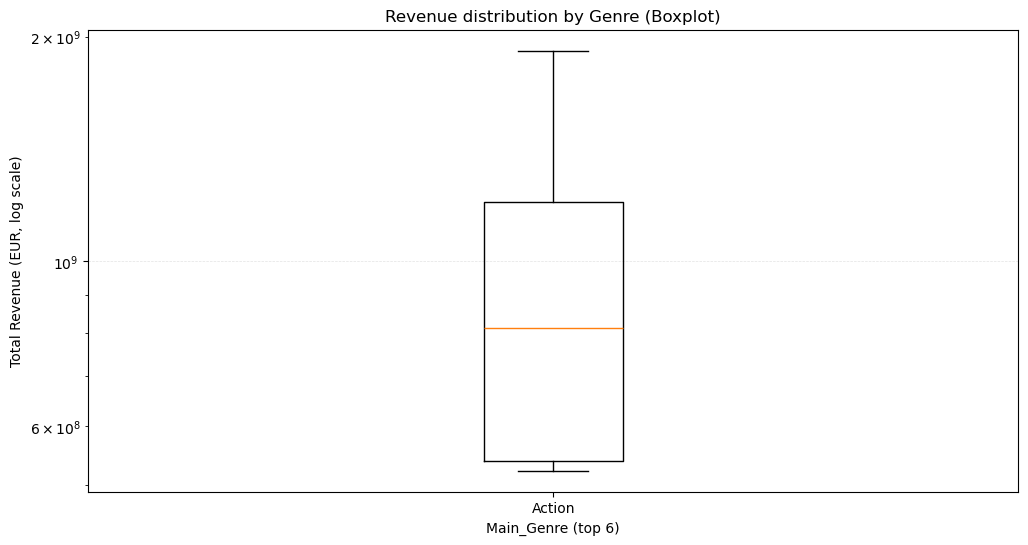

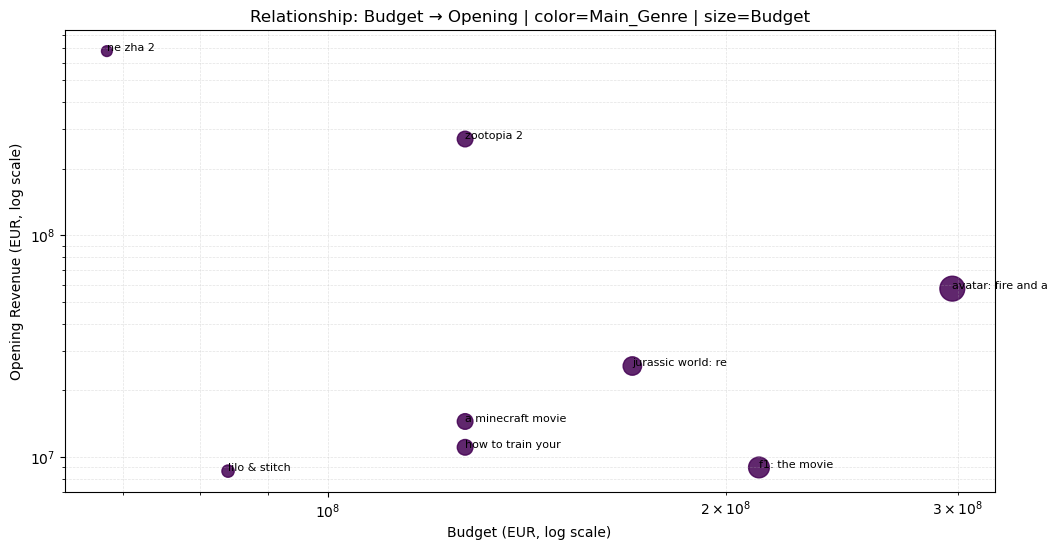

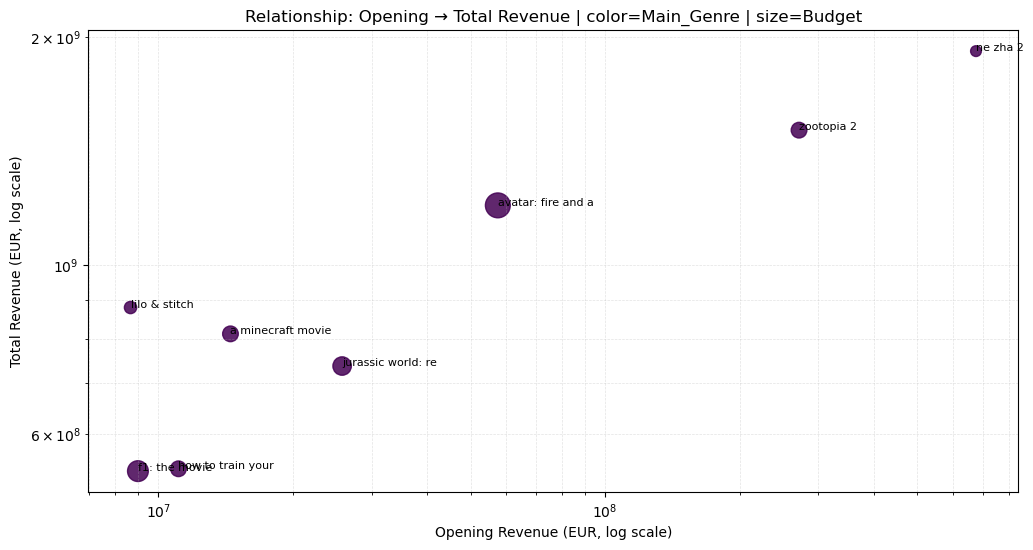

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================
# 0) 工具函数：清洗 & 解析
# =========================
def norm_movie(x):
    if pd.isna(x):
        return x
    return str(x).strip().lower()

def parse_budget_eur(x):
    # '68 milioni' / '1.2 miliardi' / 纯数字
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if s in ["-", "nan", "none", ""]: return np.nan
    m = re.search(r"(\d+(?:[.,]\d+)?)", s)
    if not m: return np.nan
    num = float(m.group(1).replace(",", "."))
    if "miliard" in s: return num * 1e9
    if "milion"  in s: return num * 1e6
    return num

def parse_money_number(x):
    # '1,916,284,213' / '€1,234,000' / '1234000'
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.lower() in ["-", "nan", "none", ""]: return np.nan
    s = re.sub(r"[\$,€]", "", s)
    s = s.replace(" ", "").replace(",", "")
    s = re.sub(r"[^0-9\.]", "", s)
    if s == "": return np.nan
    return float(s)

def parse_rating_value(x):
    # '7.9/10' -> 7.9
    if pd.isna(x): return np.nan
    s = str(x).strip().lower().replace("/10", "")
    try: return float(s)
    except: return np.nan

def pick_movie_col(df):
    # 自动识别电影名列
    candidates = ["Movie", "Nome del film", "Nome film", "Titolo", "Title", "Film"]
    for c in candidates:
        if c in df.columns:
            return c
    return df.columns[0]  # 兜底：第一列

def pick_value_col(df, exclude=("Movie",)):
    # 自动选数值列：除 Movie 外第一列
    cols = [c for c in df.columns if c not in exclude]
    return cols[0] if cols else None

def drop_unnamed(df):
    df = df.copy()
    df.drop(columns=[c for c in df.columns if "Unnamed" in c], inplace=True, errors="ignore")
    df.columns = df.columns.str.strip()
    return df

# =========================
# 1) 读取你的 CSV（固定文件名）
# =========================
budget  = drop_unnamed(pd.read_csv("Budget.csv"))
incassi = drop_unnamed(pd.read_csv("IncassiTot.csv"))
rating  = drop_unnamed(pd.read_csv("Rating.csv"))
genere  = drop_unnamed(pd.read_csv("Generefilm.csv"))
opening = drop_unnamed(pd.read_csv("opening.csv"))
nazione = drop_unnamed(pd.read_csv("Nazione.csv"))
prezzo  = drop_unnamed(pd.read_csv("PrezzoMedioTickets.csv"))

# =========================
# 2) 统一 key：Movie（自动找电影名列并改名）
# =========================
for df_ in [budget, incassi, rating, genere, opening, nazione, prezzo]:
    mcol = pick_movie_col(df_)
    df_.rename(columns={mcol: "Movie"}, inplace=True)
    df_["Movie"] = df_["Movie"].apply(norm_movie)

# =========================
# 3) 解析各表关键变量
# =========================
# Budget
if "Budget (in euro)" not in budget.columns:
    # 如果列名不同，自动选除 Movie 外第一列作为预算列
    bcol = pick_value_col(budget, exclude=("Movie",))
else:
    bcol = "Budget (in euro)"
budget["Budget_EUR"] = budget[bcol].apply(parse_budget_eur)

# Revenue
if "Incassi (in euro)" not in incassi.columns:
    rcol = pick_value_col(incassi, exclude=("Movie",))
else:
    rcol = "Incassi (in euro)"
incassi["Revenue_EUR"] = incassi[rcol].apply(parse_money_number)

# Rating value + count
if "Rating" in rating.columns:
    rating["Rating_Value"] = rating["Rating"].apply(parse_rating_value)
else:
    # 自动选除 Movie 外第一列当 Rating
    rvcol = pick_value_col(rating, exclude=("Movie",))
    rating["Rating_Value"] = rating[rvcol].apply(parse_rating_value) if rvcol else np.nan

if "numero rating" in rating.columns:
    rating["Rating_Count"] = rating["numero rating"].apply(parse_money_number)
else:
    # 自动选第二列当 count（如果有）
    cols = [c for c in rating.columns if c != "Movie"]
    rating["Rating_Count"] = rating[cols[1]].apply(parse_money_number) if len(cols) > 1 else np.nan

# Opening
oval = pick_value_col(opening, exclude=("Movie",))
opening["Opening_EUR"] = opening[oval].apply(parse_money_number) if oval else np.nan

# Ticket price
pval = pick_value_col(prezzo, exclude=("Movie",))
prezzo["TicketPrice_EUR"] = prezzo[pval].apply(parse_money_number) if pval else np.nan

# Country / Nation (可选)
nval = pick_value_col(nazione, exclude=("Movie",))
nazione["Country"] = nazione[nval].astype(str) if nval else "Unknown"

# Genre：one-hot -> Main_Genre
genre_cols = [c for c in genere.columns if c != "Movie"]
def get_main_genre(row):
    active = []
    for c in genre_cols:
        v = row.get(c, np.nan)
        try:
            if pd.notna(v) and float(v) == 1.0:
                active.append(c)
        except:
            pass
    return active[0] if active else "Unknown"
genere["Main_Genre"] = genere.apply(get_main_genre, axis=1)

# =========================
# 4) 合并主表 df（一次生成，后面所有图都用它）
# =========================
df = (
    budget[["Movie", "Budget_EUR"]]
    .merge(incassi[["Movie", "Revenue_EUR"]], on="Movie", how="inner")
    .merge(rating[["Movie", "Rating_Value", "Rating_Count"]], on="Movie", how="left")
    .merge(opening[["Movie", "Opening_EUR"]], on="Movie", how="left")
    .merge(prezzo[["Movie", "TicketPrice_EUR"]], on="Movie", how="left")
    .merge(nazione[["Movie", "Country"]], on="Movie", how="left")
    .merge(genere[["Movie", "Main_Genre"]], on="Movie", how="left")
)

df = df.dropna(subset=["Budget_EUR", "Revenue_EUR"]).copy()
df["ROI"] = df["Revenue_EUR"] / df["Budget_EUR"]

print("✅ df rows:", len(df))
display(df)

# =========================
# 5) 通用：气泡大小（默认用 Rating_Count；没有就固定）
# =========================
def bubble_sizes(series, base=60, span=260, fallback=140):
    if series is None or series.notna().sum() == 0:
        return None
    s = series.fillna(series.median()).to_numpy(float)
    smin, smax = np.nanmin(s), np.nanmax(s)
    if not (np.isfinite(smin) and np.isfinite(smax) and smax > smin):
        return None
    return base + span * (s - smin) / (smax - smin)

sizes = bubble_sizes(df["Rating_Count"])
if sizes is None:
    sizes = np.full(len(df), 140.0)
    size_title = "Fixed"
else:
    size_title = "Rating_Count"

codes, genres = pd.factorize(df["Main_Genre"].fillna("Unknown").astype(str))

# ==========================================================
# 图A：ROI vs Budget（最推荐：更清楚更“科学”）
# ==========================================================
plt.figure(figsize=(12,6))
plt.scatter(df["Budget_EUR"], df["ROI"], s=sizes, c=codes, alpha=0.85)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget (EUR, log scale)")
plt.ylabel("ROI = Revenue / Budget (log scale)")
plt.title(f"Multivariate: ROI vs Budget | color=Main_Genre | size={size_title}")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.35)

# ROI 参考线（水平线）
for k in [1, 2, 5, 10]:
    plt.axhline(k, linestyle="--", linewidth=1)
    plt.text(df["Budget_EUR"].max(), k, f" ROI={k} ", va="center", fontsize=9)

# 图例（最多10类）
max_legend = 10
handles, labels = [], []
for g in genres[:max_legend]:
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='', markersize=8))
    labels.append(str(g))
plt.legend(handles, labels, title="Main_Genre", loc="best")

for _, r in df.iterrows():
    plt.text(r["Budget_EUR"], r["ROI"], str(r["Movie"])[:18], fontsize=8)

plt.show()

# ==========================================================
# 图B：Correlation Heatmap（最 scientific）
# ==========================================================
num_cols = ["Budget_EUR", "Revenue_EUR", "ROI", "Opening_EUR", "Rating_Value", "Rating_Count", "TicketPrice_EUR"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

plt.figure(figsize=(9,7))
im = plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap (numeric variables)")
plt.colorbar(im, fraction=0.046, pad=0.04)

# 在格子里写数值（更清楚）
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.iloc[i, j]
        plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ==========================================================
# 图C：Boxplot by Genre（最清晰的类型比较）
# ==========================================================
# 只保留前 6 个最常见类型（避免太杂）
top_genres = df["Main_Genre"].value_counts().head(6).index.tolist()
d3 = df[df["Main_Genre"].isin(top_genres)].copy()

data = [d3.loc[d3["Main_Genre"]==g, "Revenue_EUR"].values for g in top_genres]

plt.figure(figsize=(12,6))
plt.boxplot(data, labels=top_genres, showfliers=True)
plt.yscale("log")
plt.xlabel("Main_Genre (top 6)")
plt.ylabel("Total Revenue (EUR, log scale)")
plt.title("Revenue distribution by Genre (Boxplot)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
plt.show()

# ==========================================================
# 图D：Budget→Opening & Opening→Revenue（因果叙事两图）
# ==========================================================
d4 = df.dropna(subset=["Opening_EUR"]).copy()
codes2, g2 = pd.factorize(d4["Main_Genre"].fillna("Unknown").astype(str))
sizes2 = bubble_sizes(d4["Budget_EUR"])
if sizes2 is None:
    sizes2 = np.full(len(d4), 140.0)

# D1: Budget vs Opening
plt.figure(figsize=(12,6))
plt.scatter(d4["Budget_EUR"], d4["Opening_EUR"], s=sizes2, c=codes2, alpha=0.85)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Budget (EUR, log scale)")
plt.ylabel("Opening Revenue (EUR, log scale)")
plt.title("Relationship: Budget → Opening | color=Main_Genre | size=Budget")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.35)
for _, r in d4.iterrows():
    plt.text(r["Budget_EUR"], r["Opening_EUR"], str(r["Movie"])[:18], fontsize=8)
plt.show()

# D2: Opening vs Revenue
plt.figure(figsize=(12,6))
plt.scatter(d4["Opening_EUR"], d4["Revenue_EUR"], s=sizes2, c=codes2, alpha=0.85)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Opening Revenue (EUR, log scale)")
plt.ylabel("Total Revenue (EUR, log scale)")
plt.title("Relationship: Opening → Total Revenue | color=Main_Genre | size=Budget")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.35)
for _, r in d4.iterrows():
    plt.text(r["Opening_EUR"], r["Revenue_EUR"], str(r["Movie"])[:18], fontsize=8)
plt.show()
